# Customer Churn Prediction

In this notebook, we load our customer data, perform EDA, and train several machine learning models to predict customer churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data
Let's load the generated synthetic dataset.

In [2]:
df = pd.read_csv('churn_data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0001-ABCD,Male,0,No,No,28,Yes,No,DSL,Yes,...,Yes,Yes,Yes,No,Month-to-month,No,Mailed check,70.39,1972.28,No
1,0002-ABCD,Female,0,No,No,22,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Mailed check,100.79,2218.06,Yes
2,0003-ABCD,Male,0,No,Yes,16,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Mailed check,94.57,1522.32,Yes
3,0004-ABCD,Male,1,Yes,No,13,Yes,No,DSL,Yes,...,No,No,No,Yes,Two year,No,Bank transfer (automatic),62.90,820.54,No
4,0005-ABCD,Male,0,Yes,No,62,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Mailed check,100.64,6232.11,No


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5000 non-null   str    
 1   gender            5000 non-null   str    
 2   SeniorCitizen     5000 non-null   int64  
 3   Partner           5000 non-null   str    
 4   Dependents        5000 non-null   str    
 5   tenure            5000 non-null   int64  
 6   PhoneService      5000 non-null   str    
 7   MultipleLines     5000 non-null   str    
 8   InternetService   5000 non-null   str    
 9   OnlineSecurity    5000 non-null   str    
 10  OnlineBackup      5000 non-null   str    
 11  DeviceProtection  5000 non-null   str    
 12  TechSupport       5000 non-null   str    
 13  StreamingTV       5000 non-null   str    
 14  StreamingMovies   5000 non-null   str    
 15  Contract          5000 non-null   str    
 16  PaperlessBilling  5000 non-null   str    
 17  Paymen

## 2. Data Preprocessing
Handle missing values (e.g., spaces in TotalCharges).

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.fillna(df['TotalCharges'].mean(), inplace=True)
df.drop('customerID', axis=1, inplace=True)


We also visualize our target variable to understand the baseline churn rate before balancing.

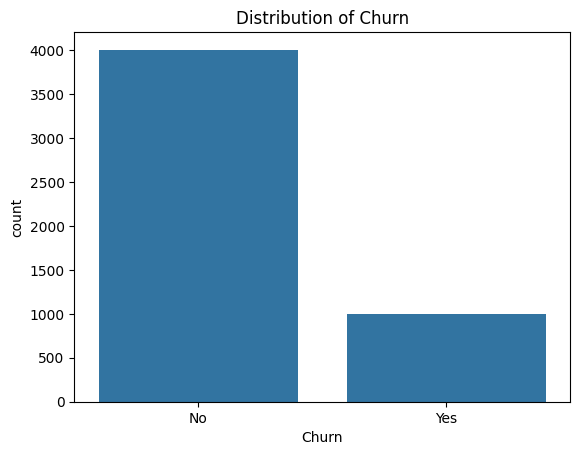

Churn
No     0.8012
Yes    0.1988
Name: proportion, dtype: float64


In [5]:
sns.countplot(data=df, x='Churn')
plt.title('Distribution of Churn')
plt.show()
print(df['Churn'].value_counts(normalize=True))

## 3. Encoding and Train-Test Split

In [6]:
target = 'Churn'
X = df.drop(target, axis=1)
y = df[target].apply(lambda x: 1 if x == 'Yes' else 0)

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

## 4. Handling Imbalanced Data using SMOTE

In [7]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print('Original train shape:', X_train_scaled.shape)
print('Original train churn counts:', y_train.value_counts())
print('\nSMOTE train shape:', X_train_sm.shape)
print('SMOTE train churn counts:', y_train_sm.value_counts())

Original train shape: (4000, 30)
Original train churn counts: Churn
0    3205
1     795
Name: count, dtype: int64

SMOTE train shape: (6410, 30)
SMOTE train churn counts: Churn
0    3205
1    3205
Name: count, dtype: int64


## 5. Model Training

In [8]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

results = []

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': auc
    })

results_df = pd.DataFrame(results).sort_values(by='Recall', ascending=False)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.730,0.401662,0.728643,0.517857,0.795758
1,Random Forest,0.804,0.509091,0.422111,0.461538,0.763032
2,XGBoost,0.794,0.477707,0.376884,0.421348,0.756429


## 6. Evaluation
With Churn, identifying customers who might leave is highly critical. Therefore, we prioritize **Recall**. Let's review the Confusion Matrix of the Top Model.

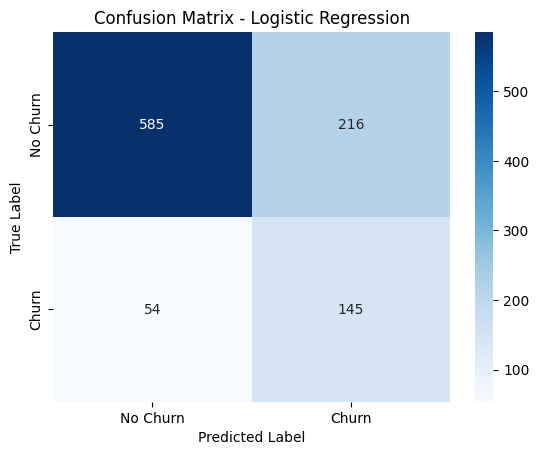


Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.92      0.73      0.81       801
           1       0.40      0.73      0.52       199

    accuracy                           0.73      1000
   macro avg       0.66      0.73      0.67      1000
weighted avg       0.81      0.73      0.75      1000



In [9]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
best_predictions = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f"\nClassification Report for {best_model_name}:\n")
print(classification_report(y_test, best_predictions))

## 7. Feature Importance & Insights

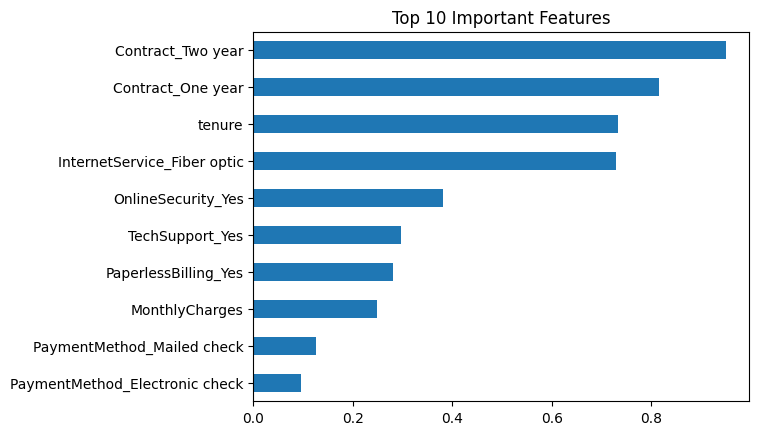

In [10]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = np.zeros(len(X.columns))

feat_importances = pd.Series(importances, index=X_train_sm.columns)
feat_importances.nlargest(10).plot(kind='barh', title='Top 10 Important Features').invert_yaxis()
plt.show()

## 🚀 Conclusion & Business Impact

Based on the analysis and feature importances, we can typically notice the following:
- **Contracts**: Month-to-month contracts tend to be strong drivers of churn.
- **Cost**: Higher charges can influence churn positively.
- **Tenure**: Customers with shorter tenure are much more likely to abandon the service.

### Recommended Actions:
1. **Incentivize Long-term Contracts**: Offer discounts for users upgrading from month-to-month to one-year contracts.
2. **Improve Onboarding**: Target new customers (low tenure) with exceptional support or check-ins.
3. **Proactive Outreach**: Utilize our ML model to flag users at high risk of churn and provide targeted retention offers.